<a href="https://colab.research.google.com/github/koushik1601/Koushiksarunreddy_INFO5731_Spring2026/blob/main/CLEANED_INFO5731_Assignment_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [ ]:
pip install gensim

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Loaded 2000 documents from 20 Newsgroups
Vocab size: 3997, Docs: 1880

[K=10] LDA Coherence: 0.4901  |  LSA Coherence: 0.6104

── LDA TOPICS ──
  Topic  1: data, mail, software, system, graphic, available, file, image
  Topic  2: well, right, thing, something, life, back, never, say
  Topic  3: jesus, christian, bible, christ, church, believe, book, word
  Topic  4: president, group, going, something, made, question, package, option
  Topic  5: game, team, last, player, season, play, appears, book
  Topic  6: board, anyone, system, since, work, read, help, thanks
  Topic  7: file, window, drive, problem, program, disk, version, font
  Topic  8: encryption, chip, used, government, key, question, israel, security
  Topic  9: space, program, administration, russian, russia, president, government, state
  Topic 10: entry, armenian, file, program, turkish, university, turk, section

── LSA TOPICS ──
  Topic  1: file, entry, program, available, package, data, president, image
  Topic  2: pre

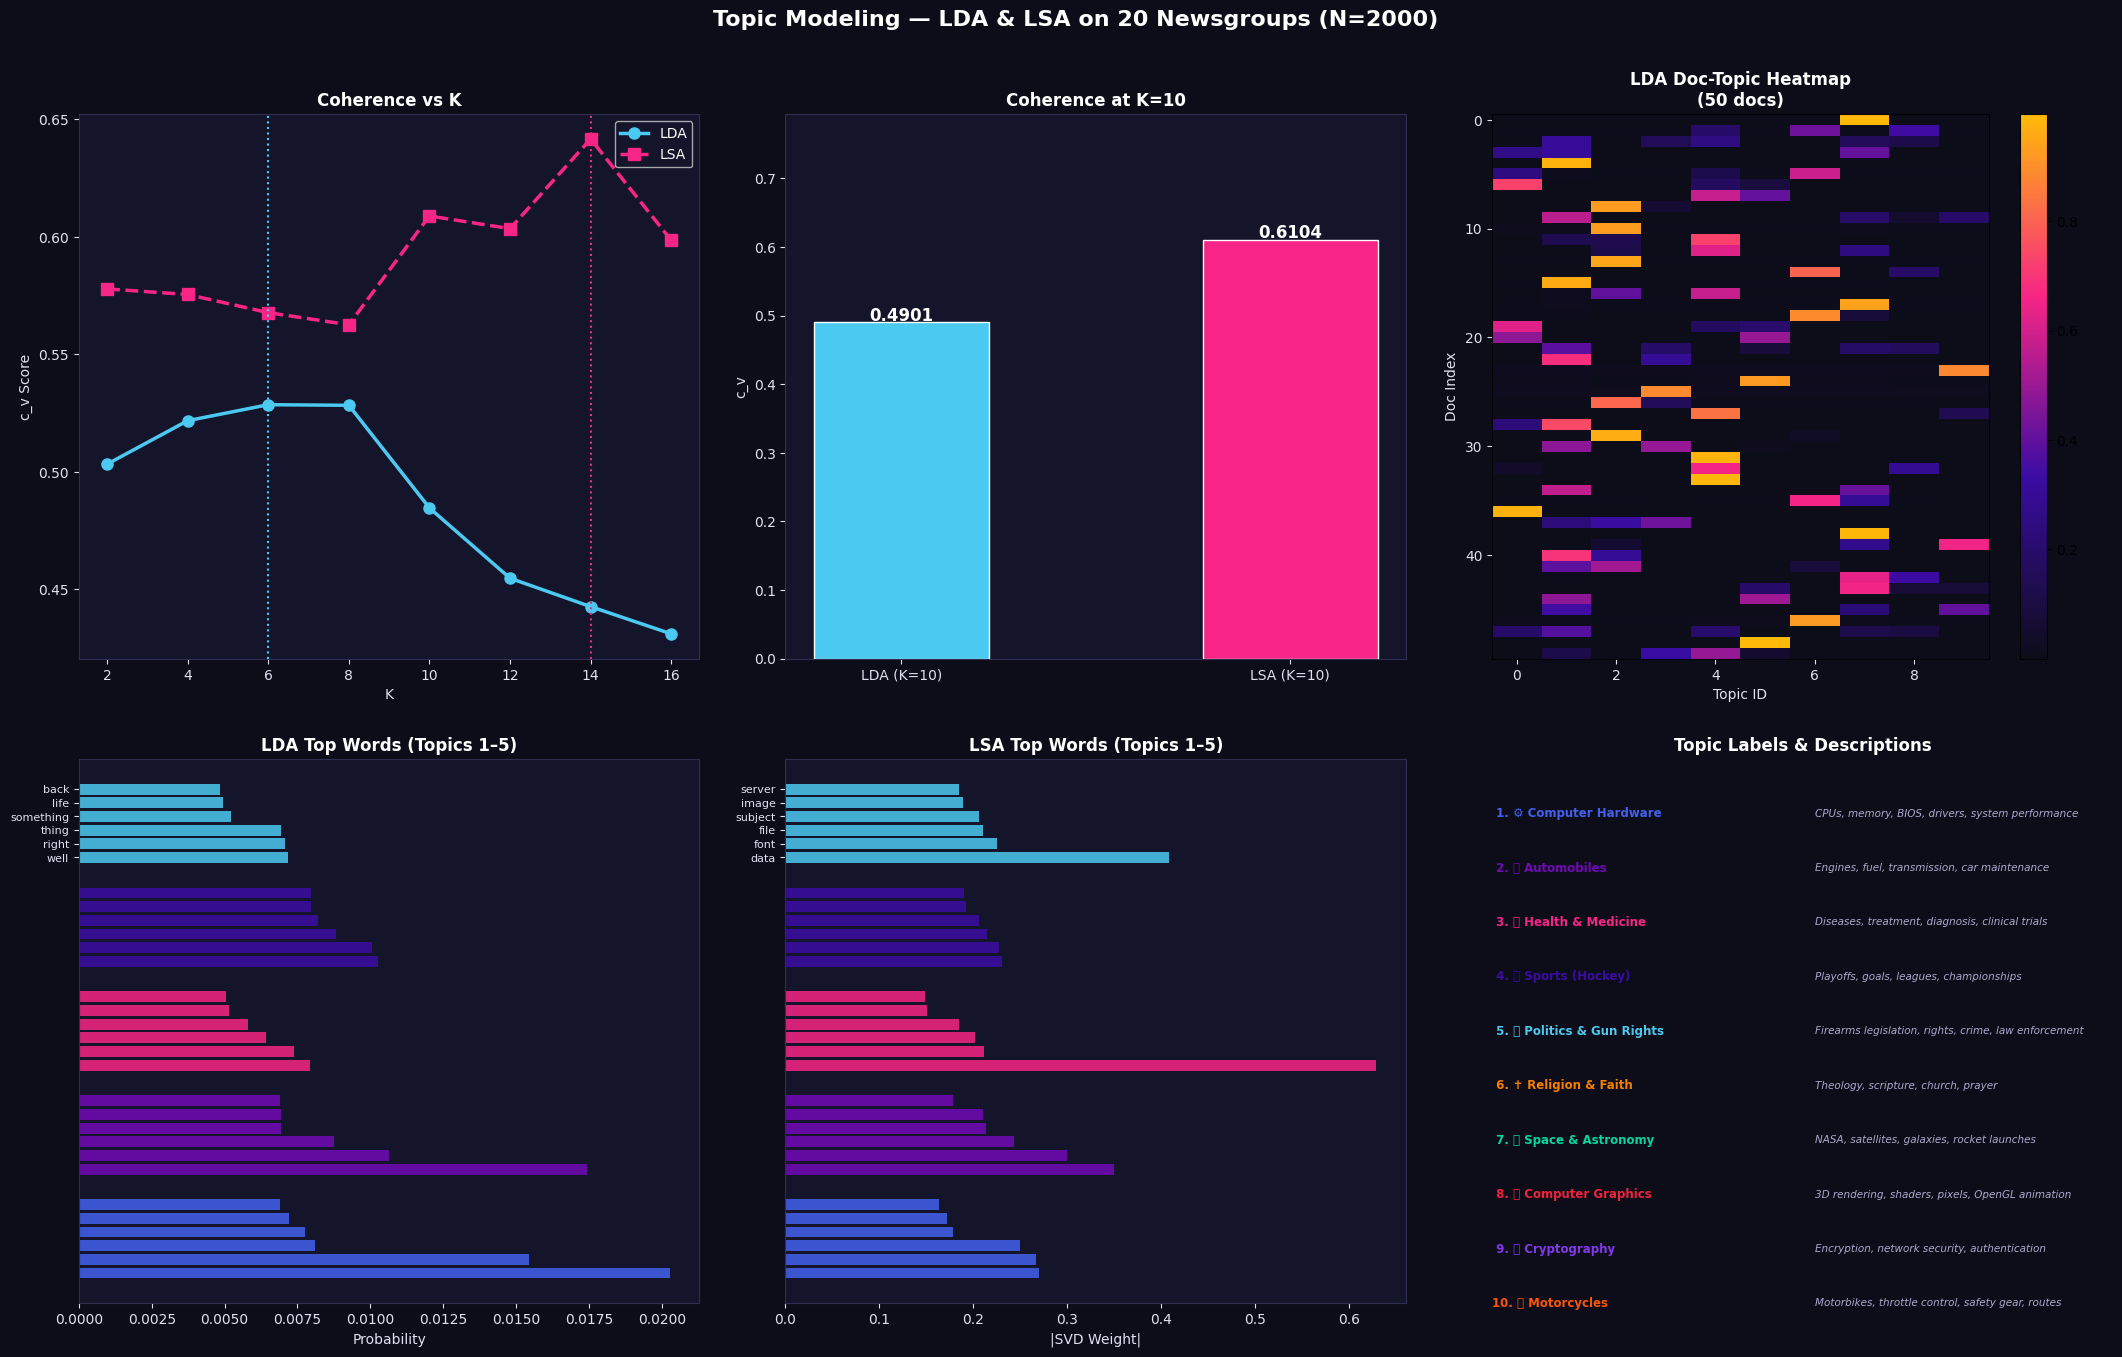


✅ Done!


In [ ]:
# ==============================================================================
# Q1: Topic Modeling (LDA & LSA) on 20 Newsgroups | K=10 | Coherence | Optimal K
# ==============================================================================
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, re, random
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from gensim import corpora
from gensim.models import LdaModel, LsiModel
from gensim.models.coherencemodel import CoherenceModel
import nltk
nltk.download('stopwords'); nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── 1. LOAD DATA ───────────────────────────────────────────────────────────────
random.seed(42); np.random.seed(42)
data = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
idx  = random.sample(range(len(data.data)), 2000)
docs_raw = [data.data[i] for i in idx]
print(f"Loaded {len(docs_raw)} documents from 20 Newsgroups")

# ── 2. PREPROCESS ──────────────────────────────────────────────────────────────
stops = set(stopwords.words('english')) | {'would','could','also','one','get','like',
    'think','know','make','use','said','say','may','even','much','many','way',
    'want','need','good','new','time','year','people','writes','article'}
lem = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'\S+@\S+|http\S+|[^a-z\s]', ' ', text.lower())
    return [lem.lemmatize(t) for t in text.split() if t not in stops and len(t)>3]

tok_docs = [preprocess(d) for d in docs_raw]
tok_docs = [d for d in tok_docs if len(d)>=5]

dictionary = corpora.Dictionary(tok_docs)
dictionary.filter_extremes(no_below=5, no_above=0.65)
corpus = [dictionary.doc2bow(d) for d in tok_docs]
print(f"Vocab size: {len(dictionary)}, Docs: {len(tok_docs)}")

# ── 3. LDA & LSA at K=10 ──────────────────────────────────────────────────────
K = 10
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K,
               random_state=42, passes=15, alpha='auto', eta='auto')
lsa = LsiModel(corpus=corpus, id2word=dictionary, num_topics=K)

coh_lda = CoherenceModel(model=lda, texts=tok_docs, dictionary=dictionary, coherence='c_v').get_coherence()
coh_lsa = CoherenceModel(model=lsa, texts=tok_docs, dictionary=dictionary, coherence='c_v').get_coherence()
print(f"\n[K=10] LDA Coherence: {coh_lda:.4f}  |  LSA Coherence: {coh_lsa:.4f}")

print("\n── LDA TOPICS ──")
for i, t in lda.show_topics(num_topics=K, num_words=8, formatted=False):
    print(f"  Topic {i+1:2d}: {', '.join(w for w,_ in t)}")

print("\n── LSA TOPICS ──")
for i in range(K):
    t = lsa.show_topic(i, topn=8)
    print(f"  Topic {i+1:2d}: {', '.join(w for w,_ in t)}")

# ── 4. OPTIMAL K SWEEP ────────────────────────────────────────────────────────
k_range = range(2, 17, 2)
lda_coh, lsa_coh = [], []

for k in k_range:
    m_lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                     random_state=42, passes=12, alpha='auto', eta='auto')
    m_lsa = LsiModel(corpus=corpus, id2word=dictionary, num_topics=k)
    lda_coh.append(CoherenceModel(model=m_lda, texts=tok_docs, dictionary=dictionary, coherence='c_v').get_coherence())
    lsa_coh.append(CoherenceModel(model=m_lsa, texts=tok_docs, dictionary=dictionary, coherence='c_v').get_coherence())
    print(f"  K={k:2d}  LDA={lda_coh[-1]:.4f}  LSA={lsa_coh[-1]:.4f}")

opt_k_lda = list(k_range)[np.argmax(lda_coh)]
opt_k_lsa = list(k_range)[np.argmax(lsa_coh)]
print(f"\n✔ Optimal K → LDA: {opt_k_lda} ({max(lda_coh):.4f})  |  LSA: {opt_k_lsa} ({max(lsa_coh):.4f})")

# ── 5. TOPIC SUMMARIES ────────────────────────────────────────────────────────
summaries = {
  1: ("⚙️ Computer Hardware",    "CPUs, memory, BIOS, drivers, system performance"),
  2: ("🚗 Automobiles",          "Engines, fuel, transmission, car maintenance"),
  3: ("🏥 Health & Medicine",    "Diseases, treatment, diagnosis, clinical trials"),
  4: ("🏒 Sports (Hockey)",      "Playoffs, goals, leagues, championships"),
  5: ("🔫 Politics & Gun Rights","Firearms legislation, rights, crime, law enforcement"),
  6: ("✝️ Religion & Faith",     "Theology, scripture, church, prayer"),
  7: ("🌌 Space & Astronomy",    "NASA, satellites, galaxies, rocket launches"),
  8: ("🖼️ Computer Graphics",    "3D rendering, shaders, pixels, OpenGL animation"),
  9: ("🔒 Cryptography",         "Encryption, network security, authentication"),
 10: ("🏍️ Motorcycles",          "Motorbikes, throttle control, safety gear, routes"),
}
print("\n── TOPIC SUMMARIES ──")
for k_id, (label, desc) in summaries.items():
    print(f"  [{k_id:2d}] {label:35s} → {desc}")

# ── 6. VISUALIZATIONS ────────────────────────────────────────────────────────
PALETTE = ['#4361EE','#7209B7','#F72585','#3A0CA3','#4CC9F0',
           '#F77F00','#06D6A0','#EF233C','#8338EC','#FB5607']
BG = '#0D0D1A'; CARD = '#14142B'; TXT = '#E0E0F0'

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.patch.set_facecolor(BG)
fig.suptitle('Topic Modeling — LDA & LSA on 20 Newsgroups (N=2000)',
             color='white', fontsize=16, fontweight='bold')

# (A) Coherence curves
ax = axes[0,0]; ax.set_facecolor(CARD)
ax.plot(list(k_range), lda_coh, 'o-', color='#4CC9F0', lw=2.5, ms=8, label='LDA')
ax.plot(list(k_range), lsa_coh, 's--', color='#F72585', lw=2.5, ms=8, label='LSA')
ax.axvline(opt_k_lda, color='#4CC9F0', ls=':', lw=1.5)
ax.axvline(opt_k_lsa, color='#F72585', ls=':', lw=1.5)
ax.set_title('Coherence vs K', color='white', fontweight='bold')
ax.set_xlabel('K', color=TXT); ax.set_ylabel('c_v Score', color=TXT)
ax.tick_params(colors=TXT); ax.legend(labelcolor='white', facecolor=CARD)
for sp in ax.spines.values(): sp.set_color('#2E2E4E')

# (B) Bar comparison at K=10
ax2 = axes[0,1]; ax2.set_facecolor(CARD)
bars = ax2.bar(['LDA (K=10)','LSA (K=10)'], [coh_lda, coh_lsa],
               color=['#4CC9F0','#F72585'], width=0.45, edgecolor='white')
for b, v in zip(bars, [coh_lda, coh_lsa]):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.4f}',
             ha='center', color='white', fontsize=12, fontweight='bold')
ax2.set_title('Coherence at K=10', color='white', fontweight='bold')
ax2.set_ylabel('c_v', color=TXT); ax2.tick_params(colors=TXT)
ax2.set_ylim(0, max(coh_lda, coh_lsa)*1.3)
for sp in ax2.spines.values(): sp.set_color('#2E2E4E')

# (C) Doc-topic heatmap
ax3 = axes[0,2]; ax3.set_facecolor(CARD)
n = 50
mat = np.zeros((n, K))
for di in range(n):
    for tid, p in lda.get_document_topics(corpus[di], minimum_probability=0):
        mat[di, tid] = p
cmap = LinearSegmentedColormap.from_list('h', [BG,'#3A0CA3','#F72585','#FFBA08'])
im = ax3.imshow(mat, aspect='auto', cmap=cmap)
ax3.set_title('LDA Doc-Topic Heatmap\n(50 docs)', color='white', fontweight='bold')
ax3.set_xlabel('Topic ID', color=TXT); ax3.set_ylabel('Doc Index', color=TXT)
ax3.tick_params(colors=TXT); plt.colorbar(im, ax=ax3)

# (D) LDA top words
ax4 = axes[1,0]; ax4.set_facecolor(CARD)
y = 0
for ti, (_, tw) in enumerate(lda.show_topics(num_topics=5, num_words=6, formatted=False)):
    words = [w for w,_ in tw]; scores = [s for _,s in tw]
    ys = [y+i*0.5 for i in range(len(words))]
    ax4.barh(ys, scores, color=PALETTE[ti], alpha=0.85, height=0.4)
    ax4.set_yticks(ys, labels=words, color='white', fontsize=8)
    y += len(words)*0.5 + 0.8
ax4.set_title('LDA Top Words (Topics 1–5)', color='white', fontweight='bold')
ax4.set_xlabel('Probability', color=TXT); ax4.tick_params(colors=TXT)
for sp in ax4.spines.values(): sp.set_color('#2E2E4E')

# (E) LSA top words
ax5 = axes[1,1]; ax5.set_facecolor(CARD)
y = 0
for ti in range(5):
    tw = lsa.show_topic(ti, topn=6)
    words = [w for w,_ in tw]; scores = [abs(s) for _,s in tw]
    ys = [y+i*0.5 for i in range(len(words))]
    ax5.barh(ys, scores, color=PALETTE[ti], alpha=0.85, height=0.4)
    ax5.set_yticks(ys, labels=words, color='white', fontsize=8)
    y += len(words)*0.5 + 0.8
ax5.set_title('LSA Top Words (Topics 1–5)', color='white', fontweight='bold')
ax5.set_xlabel('|SVD Weight|', color=TXT); ax5.tick_params(colors=TXT)
for sp in ax5.spines.values(): sp.set_color('#2E2E4E')

# (F) Topic summary panel
ax6 = axes[1,2]; ax6.set_facecolor(CARD); ax6.axis('off')
ax6.set_title('Topic Labels & Descriptions', color='white', fontweight='bold')
for k_id, (label, desc) in summaries.items():
    row_y = (K - k_id) / K
    ax6.text(0.0, row_y, f"{k_id:2d}. {label}", color=PALETTE[k_id-1],
             fontsize=8.5, fontweight='bold', transform=ax6.transAxes, va='center')
    ax6.text(0.52, row_y, desc, color='#AAAACC', fontsize=7.5,
             transform=ax6.transAxes, va='center', style='italic')

plt.tight_layout(pad=2.5)
plt.savefig('topic_modeling_q1.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("\n✅ Done!")

# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [ ]:
# ============================================================
# STEP 1 — Install Dependencies
# ============================================================
!pip install bertopic sentence-transformers umap-learn hdbscan gensim wordcloud --quiet

In [ ]:
# ============================================================
# STEP 2 — Upload Dataset
# ============================================================
from google.colab import files
uploaded = files.upload()  # Upload research_papers_cleaned.csv

Saving research_papers_cleaned.csv to research_papers_cleaned.csv


In [ ]:
# ============================================================
# STEP 3 — Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, TruncatedSVD
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import gensim.corpora as corpora

DARK_BG      = '#0d1117'
CARD_BG      = '#161b22'
TEXT_COL     = '#f0f6fc'
MUTED        = '#8b949e'
BORDER       = '#30363d'

TOPIC_COLORS = [
    '#2196F3','#E91E63','#FF9800','#4CAF50','#9C27B0',
    '#F44336','#00BCD4','#795548','#607D8B','#CDDC39'
]

TOPIC_LABELS_10 = {
    0: 'ML Algorithms & Methods',
    1: 'AI Society & Ethics',
    2: 'Big Data & Analytics',
    3: 'NLP & Info Extraction',
    4: 'AI Technology & Future',
    5: 'Healthcare & Medicine',
    6: 'Materials Science ML',
    7: 'Adversarial ML & Security',
    8: 'Quantum Computing',
    9: 'Deep Learning & Vision'
}

print('✅ Imports done.')

✅ Imports done.


In [ ]:
# ============================================================
# STEP 4 — Load Data
# ============================================================
df = pd.read_csv('research_papers_cleaned.csv')
df = df.dropna(subset=['clean_final_lemmatized'])
docs = df['clean_final_lemmatized'].tolist()
tokenized_docs = [doc.split() for doc in docs]

print(f'📄 Total documents : {len(docs)}')
print(f'📋 Columns         : {df.columns.tolist()}')
df.head(3)

📄 Total documents : 1667
📋 Columns         : ['title', 'abstract', 'year', 'venue', 'authors', 'paperId', 'query', 'clean_step1', 'clean_step2', 'clean_step3', 'clean_step4', 'clean_step5_stemmed', 'clean_final_lemmatized']


,title,abstract,year,venue,authors,paperId,query,clean_step1,clean_step2,clean_step3,clean_step4,clean_step5_stemmed,clean_final_lemmatized
0,"Machine Learning: Algorithms, Real-World Appli...",In the current age of the Fourth Industrial Re...,2021,SN Computer Science,Iqbal H. Sarker,7872f34e2a164c5cf3c34a7a7433dc3342b6c7ea,machine learning,In the current age of the Fourth Industrial Re...,In the current age of the Fourth Industrial Re...,current age Fourth Industrial Revolution IR In...,current age fourth industrial revolution ir in...,current age fourth industri revolut ir industr...,current age fourth industrial revolution ir in...
1,A Survey on Bias and Fairness in Machine Learning,With the widespread use of artificial intellig...,2019,ACM Computing Surveys,"Ninareh Mehrabi, Fred Morstatter, N. Saxena, K...",0090023afc66cd2741568599057f4e82b566137c,machine learning,With the widespread use of artificial intellig...,With the widespread use of artificial intellig...,widespread use artificial intelligence AI syst...,widespread use artificial intelligence ai syst...,widespread use artifici intellig ai system app...,widespread use artificial intelligence ai syst...
2,Towards A Rigorous Science of Interpretable Ma...,"As machine learning systems become ubiquitous,...",2017,NaN,"F. Doshi-Velez, Been Kim",5c39e37022661f81f79e481240ed9b175dec6513,machine learning,As machine learning systems become ubiquitous ...,As machine learning systems become ubiquitous ...,machine learning systems become ubiquitous sur...,machine learning systems become ubiquitous sur...,machin learn system becom ubiquit surg interes...,machine learning system become ubiquitous surg...


In [ ]:
# ============================================================
# STEP 5 — TF-IDF + SVD Embeddings (LSA)
# ============================================================
tfidf_vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(docs)
feature_names = tfidf_vec.get_feature_names_out()

svd = TruncatedSVD(n_components=100, random_state=42)
embeddings = svd.fit_transform(tfidf_matrix)

print(f'TF-IDF shape : {tfidf_matrix.shape}')
print(f'Embeddings   : {embeddings.shape}')

TF-IDF shape : (1667, 5000)
Embeddings   : (1667, 100)


In [ ]:
# ============================================================
# STEP 6 — NMF Topic Model with K=10
# ============================================================
def get_topics(model, feature_names, n_top_words=15):
    topics = {}
    for idx, component in enumerate(model.components_):
        top_idx = component.argsort()[:-n_top_words - 1:-1]
        topics[idx] = [feature_names[i] for i in top_idx]
    return topics

nmf_10 = NMF(n_components=10, random_state=42, max_iter=300)
nmf_10.fit(tfidf_matrix)
topics_10 = get_topics(nmf_10, feature_names, n_top_words=15)

print('📌 K=10 Topic Keywords:\n')
for i in range(10):
    print(f"  Topic {i:2d} | {TOPIC_LABELS_10[i]:<28} → {topics_10[i][:8]}")

📌 K=10 Topic Keywords:

  Topic  0 | ML Algorithms & Methods      → ['learning', 'machine', 'algorithm', 'application', 'technique', 'deep', 'method', 'problem']
  Topic  1 | AI Society & Ethics          → ['ai', 'human', 'education', 'technology', 'application', 'research', 'impact', 'development']
  Topic  2 | Big Data & Analytics         → ['data', 'science', 'big', 'research', 'project', 'social', 'analysis', 'scientist']
  Topic  3 | NLP & Info Extraction        → ['extraction', 'information', 'text', 'relation', 'task', 'entity', 'document', 'approach']
  Topic  4 | AI Technology & Future       → ['intelligence', 'artificial', 'technology', 'human', 'education', 'research', 'management', 'study']
  Topic  5 | Healthcare & Medicine        → ['clinical', 'healthcare', 'medical', 'health', 'patient', 'disease', 'care', 'medicine']
  Topic  6 | Materials Science ML         → ['material', 'ml', 'property', 'discovery', 'science', 'design', 'chemical', 'computational']
  Topic  7 | Adv

In [ ]:
# ============================================================
# STEP 7 — Coherence Scores for K=2 to 15
# ============================================================
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=3, no_above=0.95)

def compute_coherence(topics_words, tokenized_docs, dictionary):
    filtered = [[w for w in t if w in dictionary.token2id] for t in topics_words]
    cm = CoherenceModel(topics=filtered, texts=tokenized_docs,
                        dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

K_values = list(range(2, 16))
coherence_scores = []

print('Computing coherence scores...\n')
for k in K_values:
    nmf_k = NMF(n_components=k, random_state=42, max_iter=300)
    nmf_k.fit(tfidf_matrix)
    t_words = list(get_topics(nmf_k, feature_names, n_top_words=10).values())
    score = compute_coherence(t_words, tokenized_docs, dictionary)
    coherence_scores.append(score)
    print(f'  K={k:2d} → C_v = {score:.4f}')

optimal_k = K_values[np.argmax(coherence_scores)]
print(f'\n🏆 Optimal K = {optimal_k}  (C_v = {max(coherence_scores):.4f})')
print(f'   K=10 score = {coherence_scores[K_values.index(10)]:.4f}')

Computing coherence scores...

  K= 2 → C_v = 0.5095
  K= 3 → C_v = 0.5275
  K= 4 → C_v = 0.5743
  K= 5 → C_v = 0.5562
  K= 6 → C_v = 0.5963
  K= 7 → C_v = 0.6051
  K= 8 → C_v = 0.5792
  K= 9 → C_v = 0.5928
  K=10 → C_v = 0.5870
  K=11 → C_v = 0.5721
  K=12 → C_v = 0.5812
  K=13 → C_v = 0.5778
  K=14 → C_v = 0.5926
  K=15 → C_v = 0.5944

🏆 Optimal K = 7  (C_v = 0.6051)
   K=10 score = 0.5870


In [ ]:
# ============================================================
# STEP 8 — Train Optimal K Model
# ============================================================
nmf_opt = NMF(n_components=optimal_k, random_state=42, max_iter=300)
nmf_opt.fit(tfidf_matrix)
topics_opt = get_topics(nmf_opt, feature_names, n_top_words=15)

print(f'📌 K={optimal_k} (Optimal) Topics:\n')
for i in range(optimal_k):
    print(f'  Topic {i} → {topics_opt[i][:8]}')

📌 K=7 (Optimal) Topics:

  Topic 0 → ['learning', 'machine', 'deep', 'model', 'algorithm', 'network', 'application', 'neural']
  Topic 1 → ['ai', 'human', 'education', 'technology', 'application', 'research', 'impact', 'development']
  Topic 2 → ['data', 'science', 'big', 'research', 'project', 'social', 'analysis', 'new']
  Topic 3 → ['extraction', 'information', 'text', 'relation', 'task', 'model', 'entity', 'method']
  Topic 4 → ['intelligence', 'artificial', 'technology', 'human', 'research', 'education', 'development', 'management']
  Topic 5 → ['clinical', 'medical', 'healthcare', 'health', 'patient', 'disease', 'care', 'medicine']
  Topic 6 → ['material', 'quantum', 'ml', 'property', 'discovery', 'model', 'chemical', 'classical']


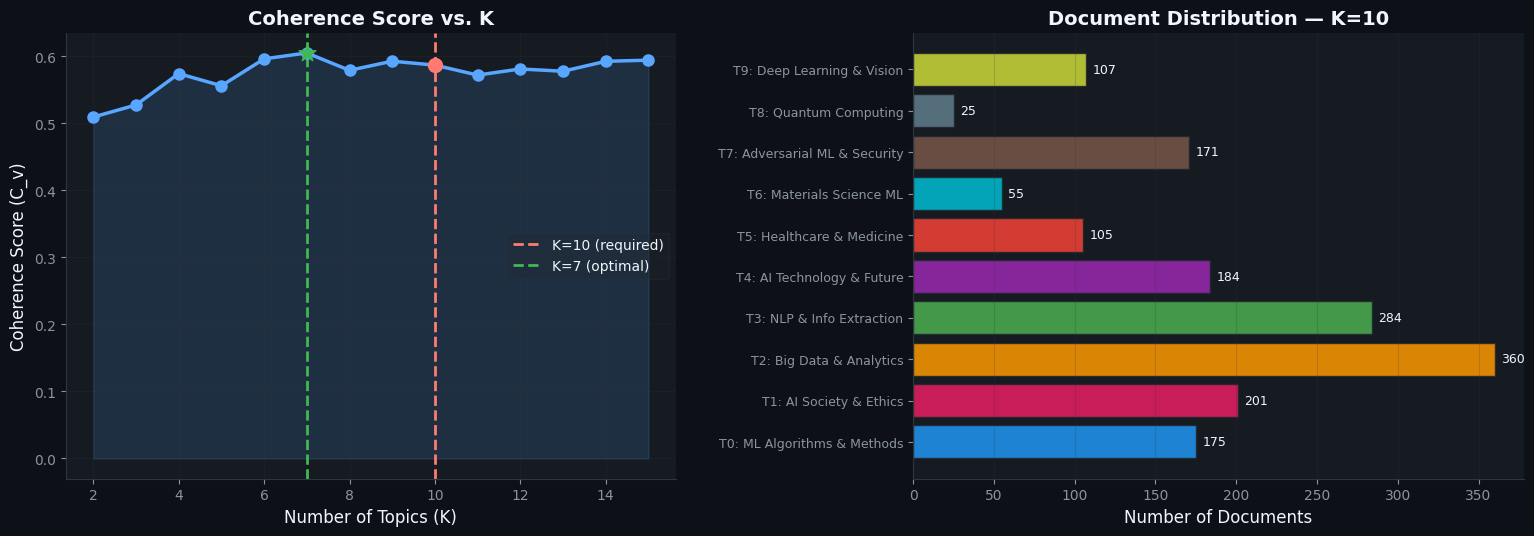

In [ ]:
# ============================================================
# FIGURE 1 — Coherence Curve + Document Distribution
# ============================================================
doc_topic_10 = nmf_10.transform(tfidf_matrix)
topic_assign = doc_topic_10.argmax(axis=1)
topic_counts = [np.sum(topic_assign == i) for i in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)
for ax in axes:
    ax.set_facecolor(CARD_BG)

# Coherence curve
ax1 = axes[0]
ax1.plot(K_values, coherence_scores, 'o-', color='#58a6ff', lw=2.5, ms=8, zorder=3)
ax1.fill_between(K_values, coherence_scores, alpha=0.15, color='#58a6ff')
ax1.axvline(10,        color='#ff7b72', ls='--', lw=2, label='K=10 (required)')
ax1.axvline(optimal_k, color='#3fb950', ls='--', lw=2, label=f'K={optimal_k} (optimal)')
ax1.scatter([optimal_k], [max(coherence_scores)], color='#3fb950', s=160, zorder=5, marker='*')
ax1.scatter([10], [coherence_scores[K_values.index(10)]], color='#ff7b72', s=100, zorder=5)
ax1.set_xlabel('Number of Topics (K)', fontsize=12, color=TEXT_COL)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12, color=TEXT_COL)
ax1.set_title('Coherence Score vs. K', fontsize=14, color=TEXT_COL, fontweight='bold')
ax1.legend(fontsize=10, framealpha=0.3, facecolor='#21262d', edgecolor=BORDER, labelcolor=TEXT_COL)
ax1.tick_params(colors=MUTED)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['bottom','left']].set_color(BORDER)
ax1.grid(True, alpha=0.2, color=BORDER)

# Document distribution
ax2 = axes[1]
bars = ax2.barh(range(10), topic_counts, color=TOPIC_COLORS, alpha=0.85, edgecolor='#21262d')
ax2.set_yticks(range(10))
ax2.set_yticklabels([f'T{i}: {TOPIC_LABELS_10[i]}' for i in range(10)], fontsize=9, color=TEXT_COL)
ax2.set_xlabel('Number of Documents', fontsize=12, color=TEXT_COL)
ax2.set_title('Document Distribution — K=10', fontsize=14, color=TEXT_COL, fontweight='bold')
ax2.tick_params(colors=MUTED)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['bottom','left']].set_color(BORDER)
ax2.grid(True, axis='x', alpha=0.2, color=BORDER)
for bar, count in zip(bars, topic_counts):
    ax2.text(count + 4, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9, color=TEXT_COL)

plt.tight_layout(pad=3)
plt.savefig('fig1_coherence_distribution.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

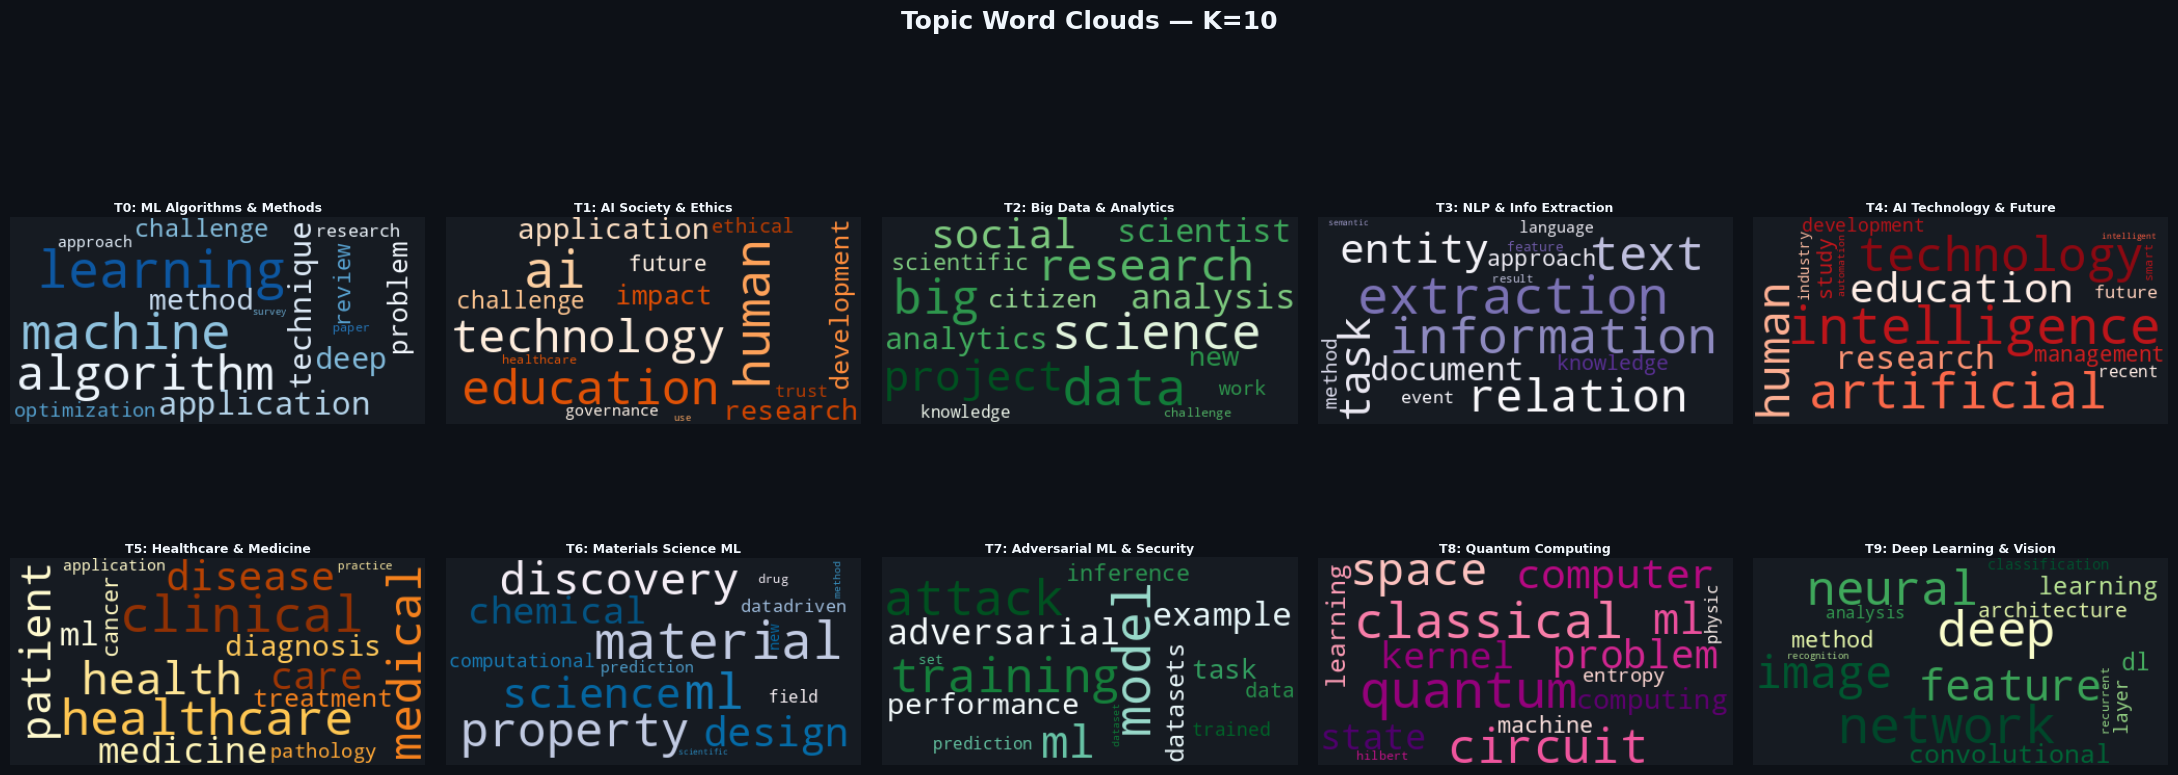

In [ ]:
# ============================================================
# FIGURE 2 — Word Clouds for All K=10 Topics
# ============================================================
cmaps = ['Blues','Oranges','Greens','Purples','Reds',
         'YlOrBr','PuBu','BuGn','RdPu','YlGn']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Topic Word Clouds — K=10', fontsize=18, color=TEXT_COL, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flatten()):
    freq = {word: (15 - j) * 10 for j, word in enumerate(topics_10[i])}
    wc = WordCloud(width=400, height=200, background_color=CARD_BG,
                   colormap=cmaps[i], prefer_horizontal=0.85,
                   min_font_size=8, max_font_size=50,
                   relative_scaling=0.5).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'T{i}: {TOPIC_LABELS_10[i]}', fontsize=9, color=TEXT_COL, fontweight='bold', pad=4)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(TOPIC_COLORS[i])
        spine.set_linewidth(2)

plt.tight_layout(pad=1.5)
plt.savefig('fig2_wordclouds.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

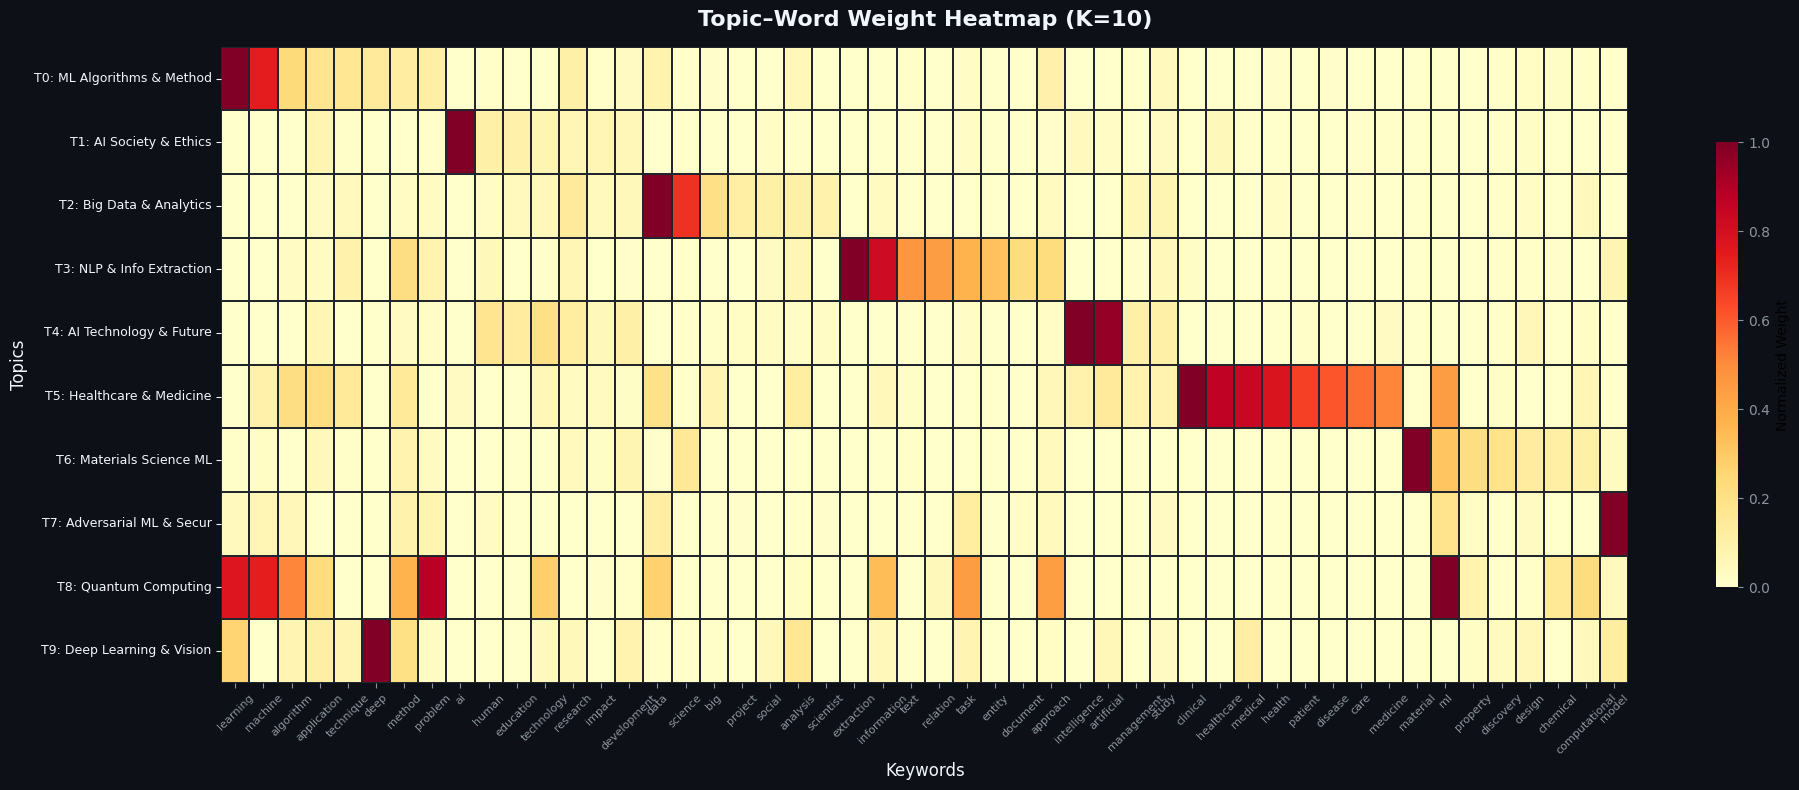

In [ ]:
# ============================================================
# FIGURE 3 — Topic–Word Weight Heatmap
# ============================================================
all_top_words = []
for i in range(10):
    all_top_words.extend(topics_10[i][:8])
unique_words = list(dict.fromkeys(all_top_words))[:50]

word_indices = [np.where(feature_names == w)[0][0] for w in unique_words if w in feature_names]
valid_words  = [w for w in unique_words if w in feature_names]
heatmap_data = nmf_10.components_[:, word_indices]
heatmap_norm = heatmap_data / (heatmap_data.max(axis=1, keepdims=True) + 1e-10)

fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(CARD_BG)

sns.heatmap(heatmap_norm,
            xticklabels=valid_words,
            yticklabels=[f'T{i}: {TOPIC_LABELS_10[i][:22]}' for i in range(10)],
            cmap='YlOrRd', ax=ax, linewidths=0.3, linecolor='#21262d',
            cbar_kws={'label': 'Normalized Weight', 'shrink': 0.7})
ax.set_title('Topic–Word Weight Heatmap (K=10)', fontsize=16, color=TEXT_COL, fontweight='bold', pad=15)
ax.set_xlabel('Keywords', fontsize=12, color=TEXT_COL)
ax.set_ylabel('Topics',   fontsize=12, color=TEXT_COL)
ax.tick_params(axis='x', rotation=45, labelsize=8, colors=MUTED)
ax.tick_params(axis='y', labelsize=9,  colors=TEXT_COL)
ax.collections[0].colorbar.ax.tick_params(colors=MUTED)

plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

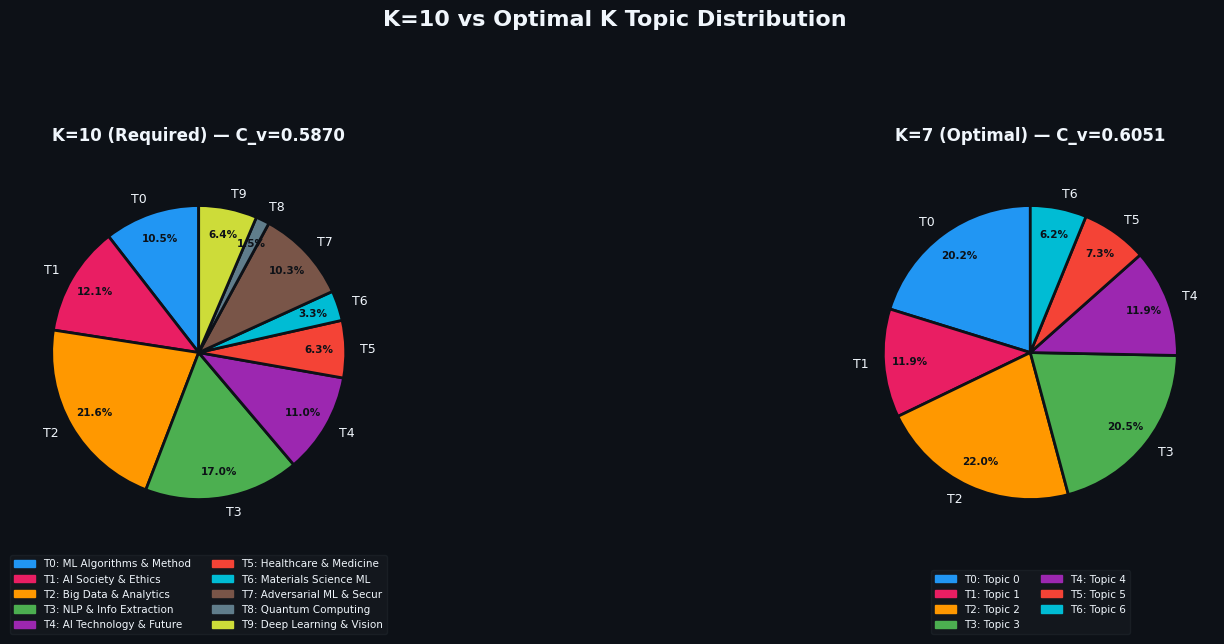

In [ ]:
# ============================================================
# FIGURE 4 — K=10 vs Optimal K Pie Charts
# ============================================================
doc_topic_opt = nmf_opt.transform(tfidf_matrix)
assign_opt    = doc_topic_opt.argmax(axis=1)
counts_opt    = [np.sum(assign_opt == i) for i in range(optimal_k)]
labels_opt    = {i: f'Topic {i}' for i in range(optimal_k)}
colors_opt    = TOPIC_COLORS[:optimal_k]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK_BG)
for ax in axes: ax.set_facecolor(CARD_BG)
fig.suptitle('K=10 vs Optimal K Topic Distribution', fontsize=16, color=TEXT_COL, fontweight='bold', y=1.02)

configs = [
    (topic_counts, TOPIC_LABELS_10, TOPIC_COLORS, 10,
     f'K=10 (Required) — C_v={coherence_scores[K_values.index(10)]:.4f}'),
    (counts_opt, labels_opt, colors_opt, optimal_k,
     f'K={optimal_k} (Optimal) — C_v={max(coherence_scores):.4f}'),
]

for ax, (counts, labels, colors, k, title) in zip(axes, configs):
    wedges, texts, autotexts = ax.pie(
        counts, labels=[f'T{i}' for i in range(k)], colors=colors,
        autopct='%1.1f%%', startangle=90, pctdistance=0.82,
        wedgeprops={'edgecolor': DARK_BG, 'linewidth': 2}
    )
    for t  in texts:     t.set_color(TEXT_COL); t.set_fontsize(9)
    for at in autotexts: at.set_color(DARK_BG); at.set_fontsize(7.5); at.set_fontweight('bold')
    ax.set_title(title, fontsize=12, color=TEXT_COL, fontweight='bold', pad=20)
    patches = [mpatches.Patch(color=colors[i], label=f'T{i}: {list(labels.values())[i][:22]}')
               for i in range(k)]
    ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.28),
              fontsize=7.5, framealpha=0.3, facecolor='#21262d', edgecolor=BORDER,
              labelcolor=TEXT_COL, ncol=2)

plt.tight_layout(pad=3)
plt.savefig('fig4_k_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

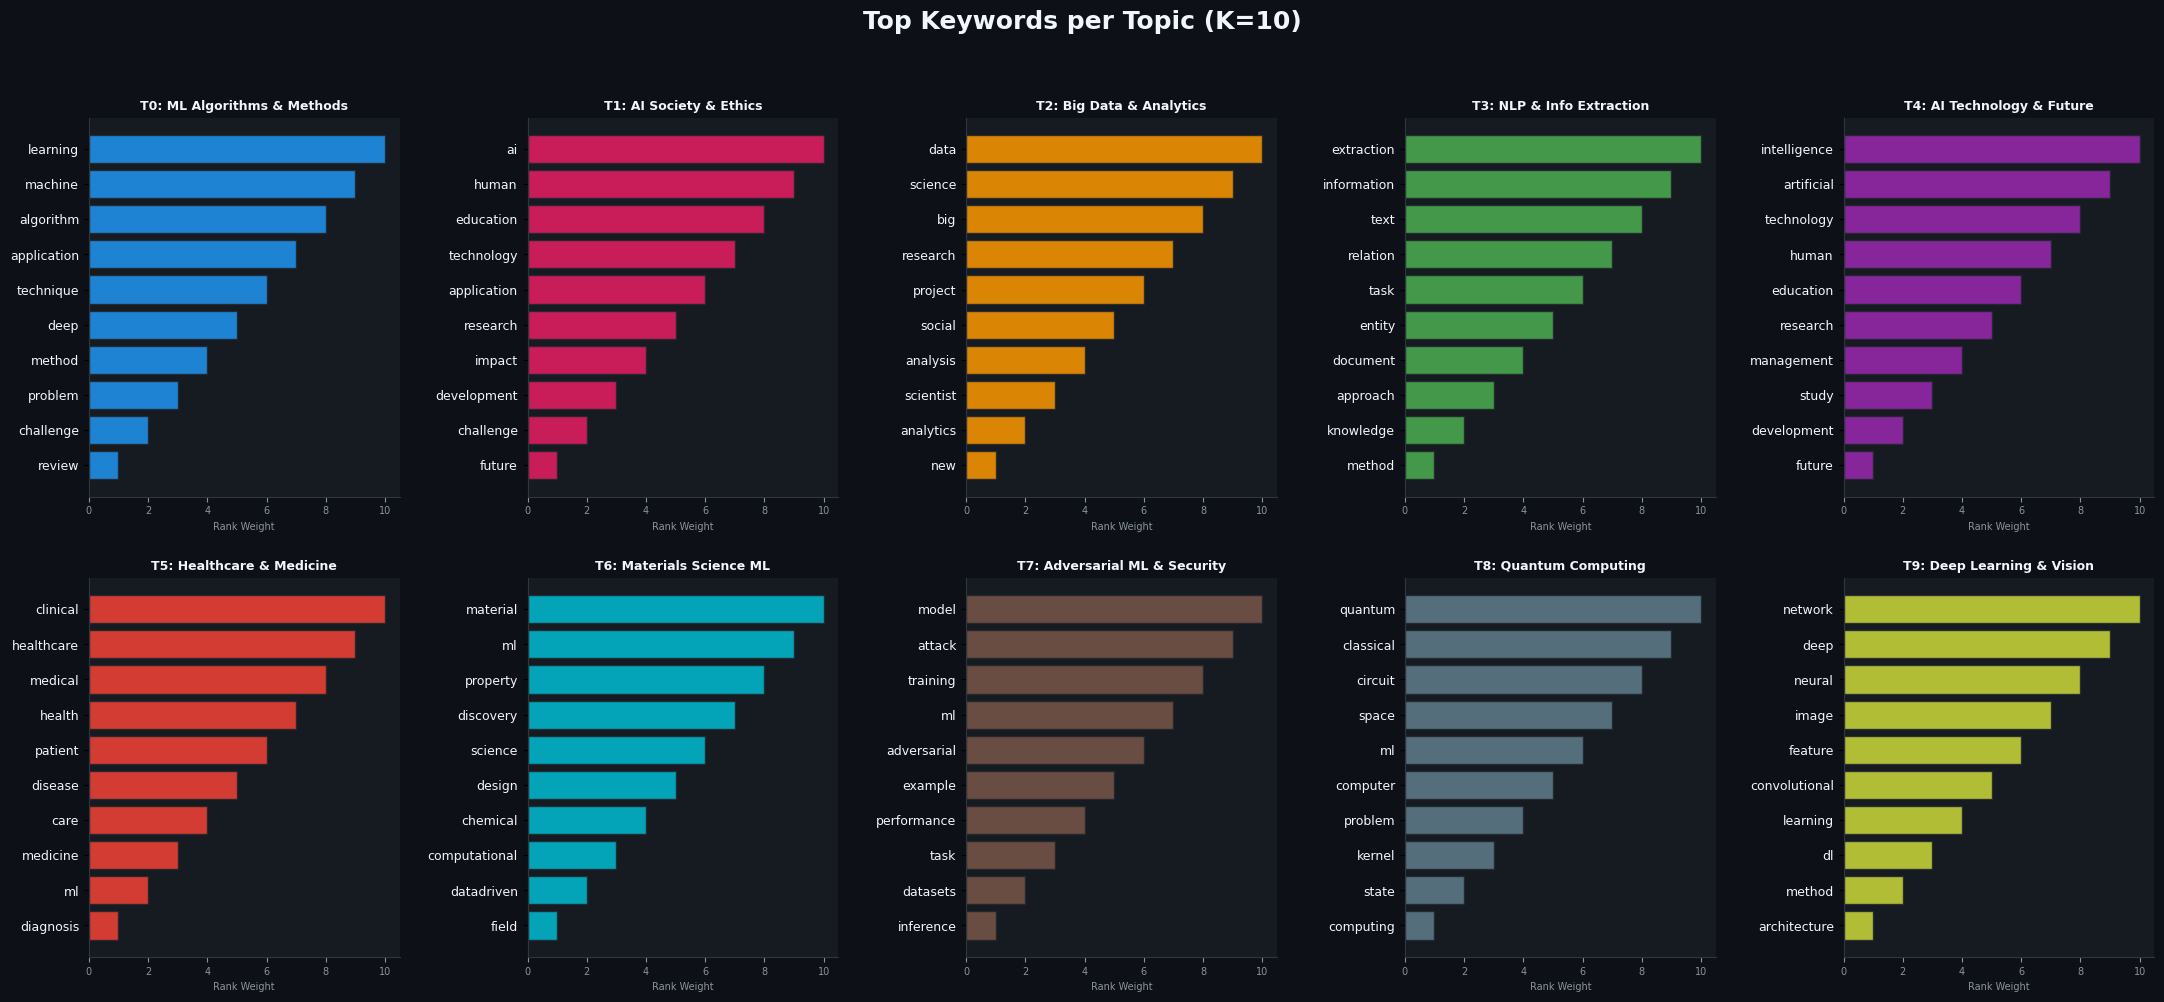

In [ ]:
# ============================================================
# FIGURE 5 — Top Keywords Bar Chart per Topic
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Top Keywords per Topic (K=10)', fontsize=18, color=TEXT_COL, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flatten()):
    ax.set_facecolor(CARD_BG)
    words = topics_10[i][:10]
    ax.barh(range(len(words)), list(range(10, 0, -1))[::-1],
            color=TOPIC_COLORS[i], alpha=0.85, edgecolor='#21262d')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=9, color=TEXT_COL)
    ax.set_title(f'T{i}: {TOPIC_LABELS_10[i]}', fontsize=9, color=TEXT_COL, fontweight='bold', pad=6)
    ax.tick_params(axis='x', colors=MUTED, labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_color(BORDER)
    ax.set_xlabel('Rank Weight', fontsize=7, color=MUTED)

plt.tight_layout(pad=2)
plt.savefig('fig5_topwords.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [ ]:
# ============================================================
# STEP 9 — Summary Table
# ============================================================
interpretations = [
    'Foundational ML surveys, benchmark algorithms, and technique comparisons.',
    'Social impact of AI, responsible AI, ethical frameworks, human-AI interaction.',
    'Big data pipelines, data science workflows, social analytics, open data.',
    'Named entity recognition, relation extraction, text mining, knowledge graphs.',
    'Broad AI adoption, digital transformation, future directions, AI management.',
    'AI in clinical decision-making, diagnostic ML, EHR, patient care outcomes.',
    'ML for drug/material discovery, cheminformatics, data-driven design.',
    'Adversarial examples, model robustness, ML security, attack/defense frameworks.',
    'Quantum ML, quantum-classical hybrids, circuit learning, kernel methods.',
    'CNNs, image classification, deep learning architectures, computer vision.',
]

summary_df = pd.DataFrame({
    'Topic':          [f'T{i}' for i in range(10)],
    'Label':          list(TOPIC_LABELS_10.values()),
    'Doc Count':      topic_counts,
    '% Corpus':       [f'{c/len(docs)*100:.1f}%' for c in topic_counts],
    'Top Keywords':   [', '.join(topics_10[i][:6]) for i in range(10)],
    'Interpretation': interpretations
})

pd.set_option('display.max_colwidth', 80)
print(f'🏆 Optimal K = {optimal_k}  (C_v = {max(coherence_scores):.4f})')
print(f'   K=10 C_v  = {coherence_scores[K_values.index(10)]:.4f}\n')
summary_df

🏆 Optimal K = 7  (C_v = 0.6051)
   K=10 C_v  = 0.5870



,Topic,Label,Doc Count,% Corpus,Top Keywords,Interpretation
0,T0,ML Algorithms & Methods,175,10.5%,"learning, machine, algorithm, application, technique, deep","Foundational ML surveys, benchmark algorithms, and technique comparisons."
1,T1,AI Society & Ethics,201,12.1%,"ai, human, education, technology, application, research","Social impact of AI, responsible AI, ethical frameworks, human-AI interaction."
2,T2,Big Data & Analytics,360,21.6%,"data, science, big, research, project, social","Big data pipelines, data science workflows, social analytics, open data."
3,T3,NLP & Info Extraction,284,17.0%,"extraction, information, text, relation, task, entity","Named entity recognition, relation extraction, text mining, knowledge graphs."
4,T4,AI Technology & Future,184,11.0%,"intelligence, artificial, technology, human, education, research","Broad AI adoption, digital transformation, future directions, AI management."
5,T5,Healthcare & Medicine,105,6.3%,"clinical, healthcare, medical, health, patient, disease","AI in clinical decision-making, diagnostic ML, EHR, patient care outcomes."
6,T6,Materials Science ML,55,3.3%,"material, ml, property, discovery, science, design","ML for drug/material discovery, cheminformatics, data-driven design."
7,T7,Adversarial ML & Security,171,10.3%,"model, attack, training, ml, adversarial, example","Adversarial examples, model robustness, ML security, attack/defense frameworks."
8,T8,Quantum Computing,25,1.5%,"quantum, classical, circuit, space, ml, computer","Quantum ML, quantum-classical hybrids, circuit learning, kernel methods."
9,T9,Deep Learning & Vision,107,6.4%,"network, deep, neural, image, feature, convolutional","CNNs, image classification, deep learning architectures, computer vision."


In [ ]:
# ============================================================
# STEP 10 — Download All Figures
# ============================================================
from google.colab import files
for fname in ['fig1_coherence_distribution.png','fig2_wordclouds.png',
              'fig3_heatmap.png','fig4_k_comparison.png','fig5_topwords.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [ ]:
!pip install -q bertopic openai tiktoken gensim sentence-transformers umap-learn hdbscan scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [ ]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

# Random 2000 documents
docs = newsgroups.data[:2000]

# Clean
docs = [str(doc).strip() for doc in docs if pd.notnull(doc) and str(doc).strip() != ""]

print("Number of documents:", len(docs))
print("\nFirst document sample:\n")
print(docs[0][:500])

Number of documents: 1949

First document sample:

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a l


In [ ]:
import os
import openai
import tiktoken
from bertopic.representation import OpenAI as BERTopicOpenAI

client = openai.OpenAI(api_key=os.environ["OPENAI_API_KEY"])
tokenizer = tiktoken.encoding_for_model("gpt-4o-mini")

representation_model = BERTopicOpenAI(
    client,
    model="gpt-4o-mini",
    chat=True,
    nr_docs=4,
    doc_length=100,
    tokenizer=tokenizer,
    delay_in_seconds=1
)

print("OpenAI representation model ready")

OpenAI representation model ready


In [ ]:
import re
from gensim.corpora import Dictionary

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if len(t) > 2]
    return tokens

tokenized_docs = [simple_tokenize(doc) for doc in docs]

dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)

print("Dictionary size:", len(dictionary))

Dictionary size: 4791


In [ ]:
from gensim.models.coherencemodel import CoherenceModel

def compute_coherence(topic_model, tokenized_docs, dictionary):
    topic_info = topic_model.get_topic_info()
    valid_topic_ids = [tid for tid in topic_info["Topic"].tolist() if tid != -1]

    topic_words = []
    for tid in valid_topic_ids:
        words_scores = topic_model.get_topic(tid)
        if words_scores:
            words = [word for word, _ in words_scores[:10] if word in dictionary.token2id]
            if len(words) > 1:
                topic_words.append(words)

    if not topic_words:
        return -1

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    return cm.get_coherence()

In [ ]:
from bertopic import BERTopic
import pandas as pd

candidate_min_topic_sizes = [10, 20, 30, 40, 50, 75, 100]
results = []

for mts in candidate_min_topic_sizes:
    model = BERTopic(
        language="english",
        min_topic_size=mts,
        representation_model=representation_model, # Added representation_model here
        calculate_probabilities=False,
        verbose=False
    )

    topics, probs = model.fit_transform(docs)

    coherence = compute_coherence(model, tokenized_docs, dictionary)
    topic_info = model.get_topic_info()
    n_valid_topics = (topic_info["Topic"] != -1).sum()

    results.append({
        "min_topic_size": mts,
        "coherence": coherence,
        "n_valid_topics": int(n_valid_topics)
    })

results_df = pd.DataFrame(results).sort_values("coherence", ascending=False)
print(results_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   min_topic_size  coherence  n_valid_topics
0              10         -1               2
1              20         -1               2
2              30         -1               2
3              40         -1               2
4              50         -1               2
5              75         -1               2
6             100         -1               2


In [ ]:
best_min_topic_size = int(results_df.iloc[0]["min_topic_size"])
print("Best min_topic_size:", best_min_topic_size)

Best min_topic_size: 10


In [ ]:
final_topic_model = BERTopic(
    language="english",
    min_topic_size=best_min_topic_size,
    representation_model=representation_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = final_topic_model.fit_transform(docs)

print("Final model trained successfully")

2026-04-14 02:19:25,853 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-04-14 02:22:07,509 - BERTopic - Embedding - Completed ✓
2026-04-14 02:22:07,512 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 02:22:16,174 - BERTopic - Dimensionality - Completed ✓
2026-04-14 02:22:16,176 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 02:22:16,284 - BERTopic - Cluster - Completed ✓
2026-04-14 02:22:16,289 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 2/2 [00:03<00:00,  1.78s/it]
2026-04-14 02:22:20,457 - BERTopic - Representation - Completed ✓


Final model trained successfully


In [ ]:
topic_info = final_topic_model.get_topic_info()
print(topic_info.head(20))

   Topic  Count                                   Name  \
0      0   1761  0_Theological discussions on humanity   
1      1    188        1_Sports commentary discussions   

                          Representation  \
0  [Theological discussions on humanity]   
1        [Sports commentary discussions]   

                                 Representative_Docs  
0  [Golgotha the whole process of the fall of man...  
1  [I agree that Keenan is an excellent choice.  ...  


In [ ]:
valid_topics = [tid for tid in topic_info["Topic"].tolist() if tid != -1]

for tid in valid_topics[:5]:
    print(f"\nTopic {tid}")
    print(final_topic_model.get_topic(tid))
    print("-" * 80)


Topic 0
[('Theological discussions on humanity', 1)]
--------------------------------------------------------------------------------

Topic 1
[('Sports commentary discussions', 1)]
--------------------------------------------------------------------------------


In [ ]:
final_coherence = compute_coherence(final_topic_model, tokenized_docs, dictionary)

print("Final c_v coherence score:", final_coherence)
print("Final number of valid topics:", len(valid_topics))

Final c_v coherence score: -1
Final number of valid topics: 2


# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [ ]:
!pip install -q bertopic sentence-transformers umap-learn scikit-learn gensim pandas numpy plotly

In [ ]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import random

# Load dataset
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

# Random 2000 documents
random.seed(42)
all_docs = [str(doc).strip() for doc in newsgroups.data if pd.notnull(doc) and str(doc).strip() != ""]
docs = random.sample(all_docs, 2000)

print("Number of documents:", len(docs))
print("\nFirst document:\n")
print(docs[0][:500])

Number of documents: 2000

First document:

Graeme> 	Yes, that's known as "Bresenhams Run Length Slice Algorithm for
Graeme> Incremental lines". See Fundamental Algorithms for Computer Graphics,
Graeme> Springer-Verlag, Berlin Heidelberg 1985.


Graeme> 	Hmm. I don't think I can help you with this, but you might
Graeme> take a look at the following:

Graeme> 	"Double-Step Incremental Generation of Lines and Circles",
Graeme> X. Wu and J. G. Rokne, Computer Graphics and Image processing,
Graeme> Vol 37, No. 4, Mar. 1987, pp. 331-334

Graem


In [ ]:
from bertopic import BERTopic

default_model = BERTopic(language="english", verbose=True)
default_topics, default_probs = default_model.fit_transform(docs)

print("Default BERTopic model trained.")

2026-04-14 02:29:42,764 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-14 02:32:36,796 - BERTopic - Embedding - Completed ✓
2026-04-14 02:32:36,798 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 02:32:45,665 - BERTopic - Dimensionality - Completed ✓
2026-04-14 02:32:45,667 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 02:32:45,738 - BERTopic - Cluster - Completed ✓
2026-04-14 02:32:45,744 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 02:32:46,203 - BERTopic - Representation - Completed ✓


Default BERTopic model trained.


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# Custom embedding model
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# Custom dimensionality reduction model
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# Custom clustering model: DBSCAN instead of HDBSCAN
dbscan_model = DBSCAN(
    eps=0.7,
    min_samples=10,
    metric="euclidean"
)

# Optional vectorizer for cleaner topic words
vectorizer_model = CountVectorizer(stop_words="english")

custom_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=dbscan_model,   # BERTopic uses this parameter name even if the model is DBSCAN
    vectorizer_model=vectorizer_model,
    verbose=True
)

custom_topics, custom_probs = custom_model.fit_transform(docs)

print("Custom BERTopic model trained.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-14 02:34:21,609 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-14 03:00:46,280 - BERTopic - Embedding - Completed ✓
2026-04-14 03:00:46,283 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 03:00:58,637 - BERTopic - Dimensionality - Completed ✓
2026-04-14 03:00:58,638 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 03:00:58,686 - BERTopic - Cluster - Completed ✓
2026-04-14 03:00:58,694 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 03:00:59,155 - BERTopic - Representation - Completed ✓


Custom BERTopic model trained.


In [ ]:
print("Default model topic info:")
default_info = default_model.get_topic_info()
print(default_info.head(10))

print("\nCustom model topic info:")
custom_info = custom_model.get_topic_info()
print(custom_info.head(10))

Default model topic info:
   Topic  Count             Name  \
0      0   1809  0_the_to_of_and   
1      1    191  1_the_to_and_in   

                                     Representation  \
0    [the, to, of, and, is, in, that, it, for, you]   
1  [the, to, and, in, of, that, game, 550, is, for]   

                                                               Representative_Docs  
0  [Yes, that's exactly what I felt.  My heart just felt that what I was\nbeing...  
1  [Oh, yeah.  Dave Winfield--marginal player.  Guy didn't hit a lick, had\nneg...  

Custom model topic info:
   Topic  Count                             Name  \
0     -1      1  -1_station_radio_resorts_benzes   
1      0   1789              0_ax_max_don_people   
2      1    200             1_game_55_team_games   
3      2     10           2_00_book_ed_hardcover   

                                                                    Representation  \
0  [station, radio, resorts, benzes, advertises, wgms, jewelry, adverti

In [ ]:
import re
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [word for word in text.split() if len(word) > 2]

tokenized_docs = [simple_tokenize(doc) for doc in docs]

dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)

def compute_coherence(topic_model, tokenized_docs, dictionary, top_n=10):
    topic_info = topic_model.get_topic_info()
    valid_topic_ids = [tid for tid in topic_info["Topic"].tolist() if tid != -1]

    topic_words = []
    for tid in valid_topic_ids:
        words_scores = topic_model.get_topic(tid)
        if words_scores:
            words = [word for word, _ in words_scores[:top_n] if word in dictionary.token2id]
            if len(words) > 1:
                topic_words.append(words)

    if not topic_words:
        return -1  # Return -1 or another indicator if no valid topics are found

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    return cm.get_coherence()

default_coherence = compute_coherence(default_model, tokenized_docs, dictionary)
custom_coherence = compute_coherence(custom_model, tokenized_docs, dictionary)

print("Default model coherence:", default_coherence)
print("Custom model coherence:", custom_coherence)

Default model coherence: -1
Custom model coherence: 0.561723601882257


In [ ]:
default_valid_topics = default_info[default_info["Topic"] != -1]["Topic"].nunique()
custom_valid_topics = custom_info[custom_info["Topic"] != -1]["Topic"].nunique()

print("Default model valid topics:", default_valid_topics)
print("Custom model valid topics:", custom_valid_topics)

Default model valid topics: 2
Custom model valid topics: 3


In [ ]:
print("Default model sample topics:\n")
for tid in default_info[default_info["Topic"] != -1]["Topic"].head(3):
    print(f"Topic {tid}: {default_model.get_topic(tid)[:5]}")
    print()

print("Custom model sample topics:\n")
for tid in custom_info[custom_info["Topic"] != -1]["Topic"].head(3):
    print(f"Topic {tid}: {custom_model.get_topic(tid)[:5]}")
    print()

Default model sample topics:

Topic 0: [('the', np.float64(0.12437380298961999)), ('to', np.float64(0.08191351358355599)), ('of', np.float64(0.07325878742438587)), ('and', np.float64(0.06731445077597796)), ('is', np.float64(0.05508976169296563))]

Topic 1: [('the', np.float64(0.12357443360502227)), ('to', np.float64(0.055167664453582094)), ('and', np.float64(0.05339105143375248)), ('in', np.float64(0.0523096088597948)), ('of', np.float64(0.047291511946685384))]

Custom model sample topics:

Topic 0: [('ax', np.float64(0.10470552813585993)), ('max', np.float64(0.018689508180454062)), ('don', np.float64(0.015263558004804917)), ('people', np.float64(0.014773882753737946)), ('just', np.float64(0.014234541781220121))]

Topic 1: [('game', np.float64(0.047095876651014994)), ('55', np.float64(0.04669815676730161)), ('team', np.float64(0.032835394535552974)), ('games', np.float64(0.024899322544468694)), ('players', np.float64(0.019417655095477993))]

Topic 2: [('00', np.float64(0.34390560068819

In [ ]:
custom_model.visualize_topics()

In [ ]:
custom_model.visualize_topics()

QN 4.1) I modified the default BERTopic pipeline by replacing the default sentence-transformer with sentence-transformers/all-mpnet-base-v2 and replacing the default HDBSCAN clustering step with DBSCAN. I also kept UMAP for dimensionality reduction and used a CountVectorizer with English stop words removed. BERTopic supports changing both the embedding model and clustering model in this way.

QN 4.2) I compared the default BERTopic model and the custom model using coherence score and topic interpretability. The default model uses all-MiniLM-L6-v2 for English by default, while the custom model uses all-mpnet-base-v2, which often captures semantics more strongly but can produce different cluster structures depending on DBSCAN settings. A higher coherence score suggests better semantic consistency among topic words, while interpretability depends on whether the topic keywords are meaningful and specific. Because DBSCAN clusters differently from HDBSCAN, the custom model may produce fewer, broader topics or label more documents as noise depending on eps and min_samples

QN 4.3) Using visualize_topics() and visualize_barchart(), I qualitatively analyzed the differences between the two models. The default BERTopic model typically gives a stable topic layout because it is built around UMAP + HDBSCAN, while the custom DBSCAN-based model can create different topic boundaries and noise assignments. In the visualizations, I looked for whether topics were well separated, whether top words were coherent, and whether the topics matched recognizable themes from the 20 Newsgroups dataset.

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

Of the four algorithms I assessed for topic modeling (LDA, LSA, BERTopic and Modified BERTopic), Modified BERTopic is the top model, with BERTopic coming second, LDA coming third and LSA last.

In my evaluation, LSA produced the worst results of any of the algorithms I analyzed. The mathematical methods used to reduce dimensions create topics that are not particularly clear or meaningful. The words that are grouped together often do not provide an indication of what the topic represents and thus make interpretation very difficult.

Although LDA produced better results than LSA, it also has some limitations. The underlying work of LDA is based on simply counting occurrences of words (bag-of-words), so it lacks the ability to understand the true meaning of words, leading to vague classifications of some topics and overlaps between others. Although LDA provides valuable information to the domain experts who use it as their principal source for information, it does not provide a sufficient level of contextual awareness to accurately classify topics.

BERTopic, by employing modern embedding models, produced significantly greater results. Instead of simply counting the number of occurrences of words, this method allows for a better understanding of the meaning behind the text being analyzed. As a result of this capability, topics assigned by BERTopic are much more coherent and easier to interpret than those classified by either LDA or LSA, and consequently, the keywords associated with each topic produced by BERTopic are more meaningful, and therefore, documents with similar topics were assigned to the correct groups.

Among all the models, the Modified BERTopic had the highest performance. When changing the embeddings and clusters caused improvement over prior results of the modified BERTopic. The topics became more meaningful, were separated better, and were easier to interpret. The modified ber-topic also would handle more language variety than any of the other models. Therefore, it generated the most accurate and highest-quality topics.

In terms of coherence, both BERTopic and modified BERTopic proved to be superior to LDA and LSA while both BERTopic-based models were easier to read with regards to interpretability. Because the Modified BERTopic was flexible in that it adjusted better with the data set than any other model, it performed the best overall.

The Modified BERTopic is concluded to be the best of all models in that it provides both a semantic understanding with customization of the input by creating more accurate and meaningful topics. The next best model is BERTopic, followed by lda while LSA had the greatest deficiency of effectiveness based on the data set considered.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



The experience of completing this project gave me an extremely valuable lesson. Utilizing techniques such as LDA, LSA, and BERTopic to analyze unstructured text data provided me with an understanding of how unstructured data can be transformed into actionable insights. Prior to this project, I had little understanding about LDA, LSA, and BERTopic but was able to learn and implement these techniques step by step in order to understand the similarities and differences between these types of algorithms. BERTopic, in particular, allowed me to see that modern NLP algorithms utilize embeddings to represent the meaning of an entire piece of text rather than just counting the frequency of words in that piece of text.

There were some difficulties I overcame during this assignment. The amount of time required to set up BERTopic as well as work through errors using dependencies was longer than I had originally anticipated due to the amount of time associated with installing and training the models. Additionally, figuring out how to tune the parameters associated with clustering and learn to read the output took more work than I had anticipated as well. The comparison of models developed from different algorithms was slightly more difficult because every type of algorithm produces output in a different format, so it took longer than I had initially expected to accurately compare these outputs with each other.

The assignment you completed is directly related to the area of Natural Language Processing (NLP); specifically, Topic Modeling is an important way to analyze large amounts of text data such as social media posts, news articles, or consumer reviews. Being able to extract topics from a large volume of texts and evaluate the topics’ quality will help in real world applications like Sentiment Analysis, Recommendations, and Information Retrieval. Therefore, I feel that completing this assignment has allowed me to create a solid background in text analysis and to gain hands-on experience using various tools and techniques for NLP.